Fetching state boundary GeoJSON...
  Loaded 52 state features.


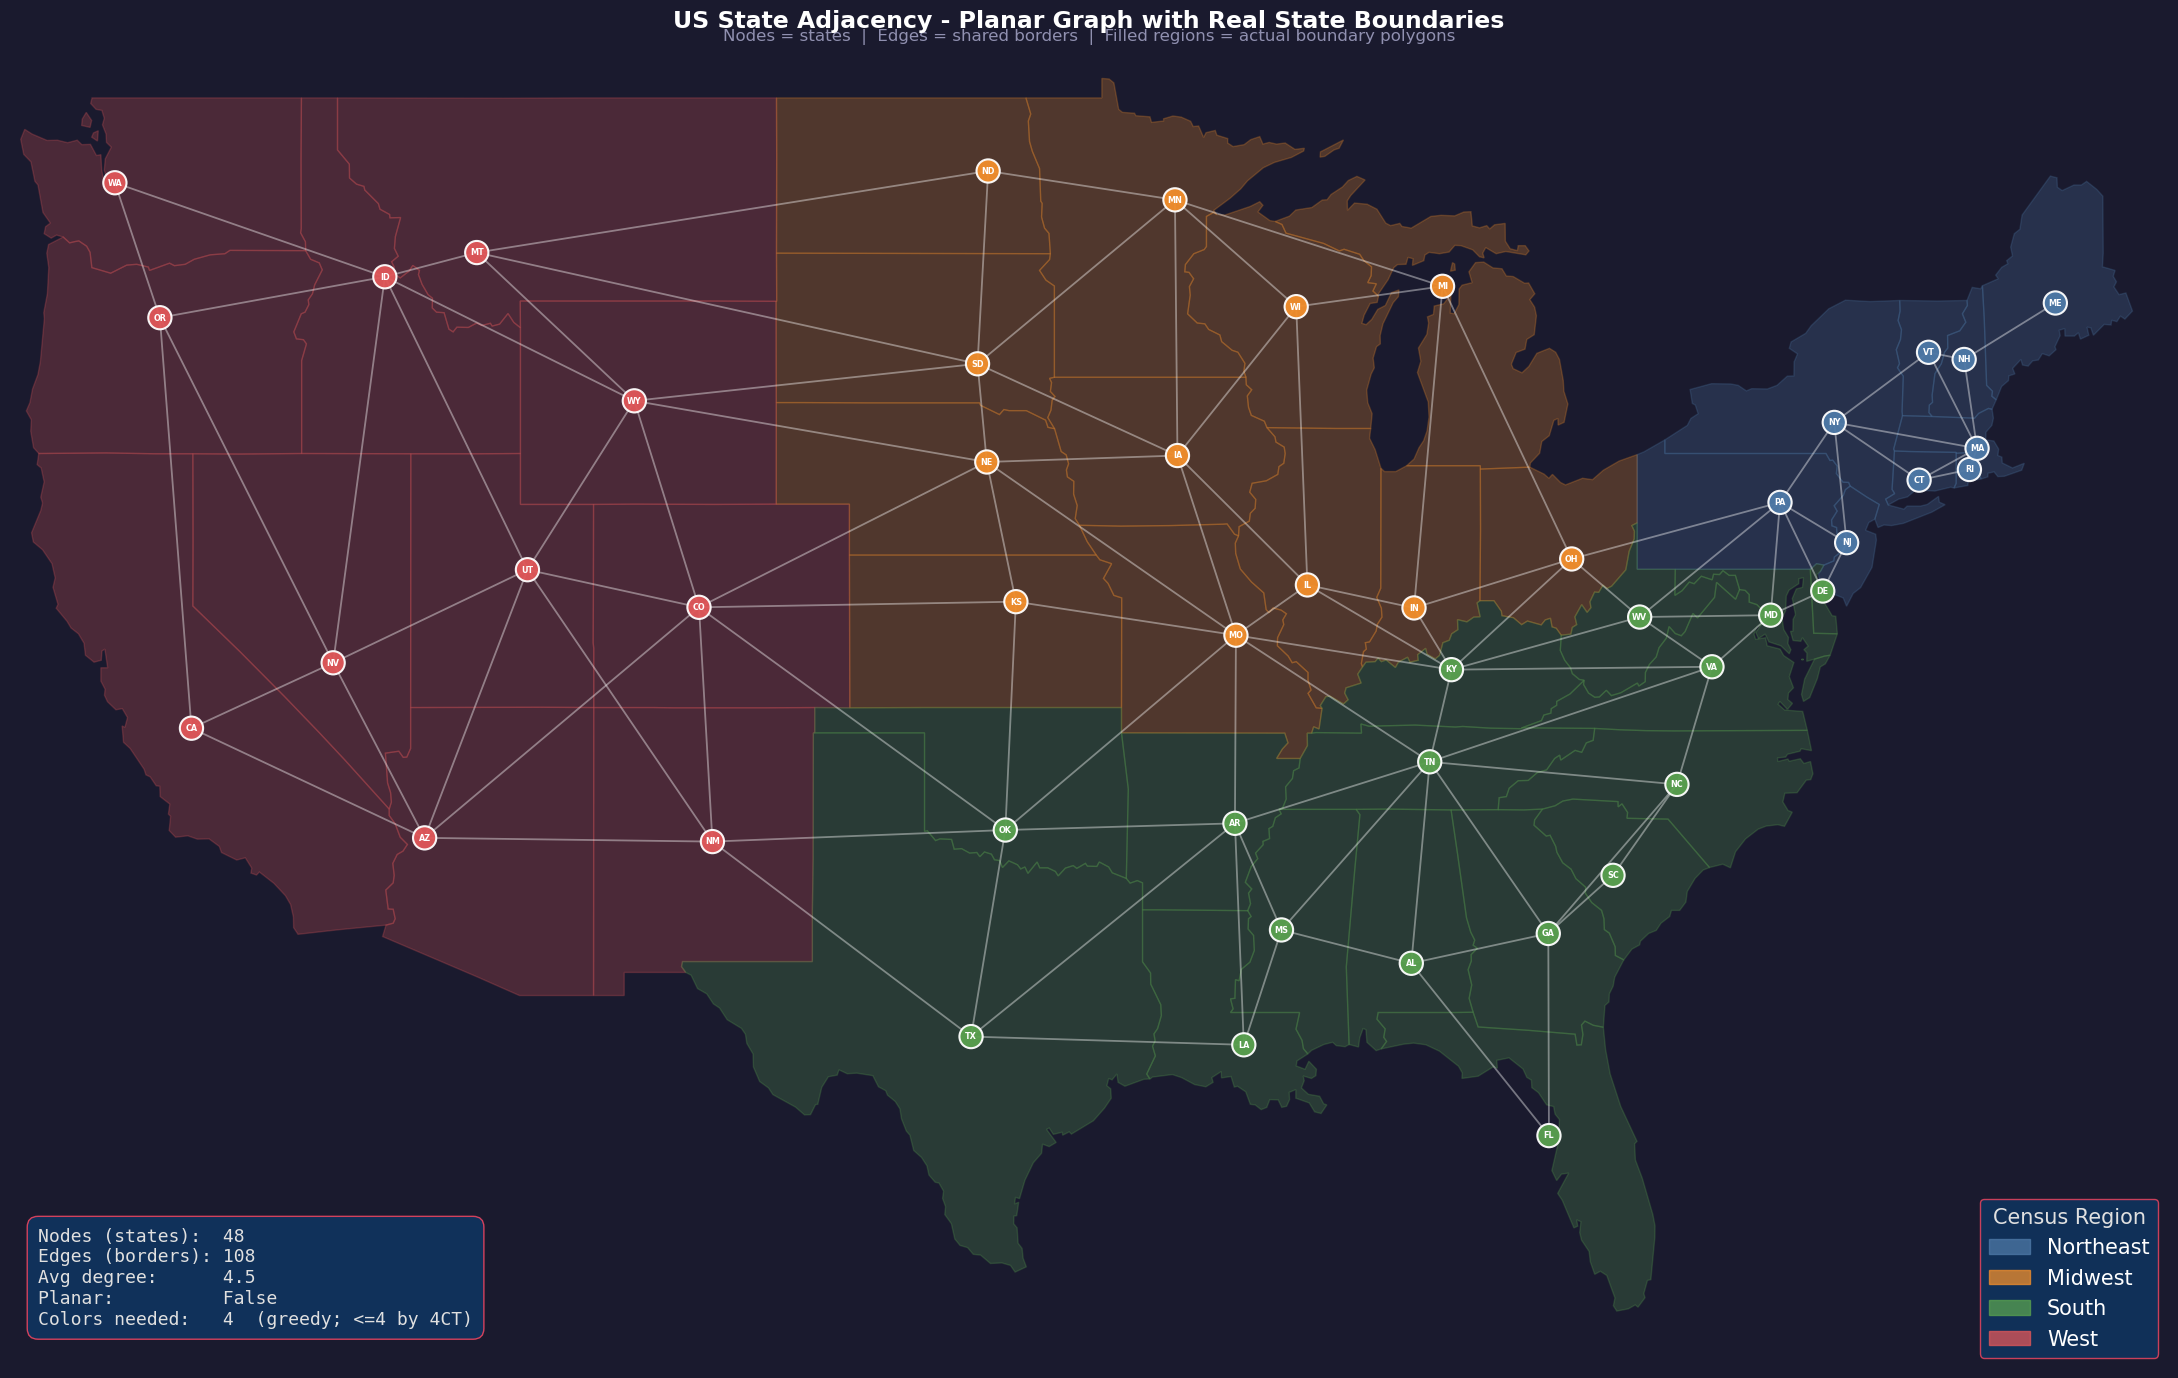

In [2]:
"""
US State Adjacency — Planar Graph with Real State Boundaries
=============================================================
Fetches actual state boundary GeoJSON at runtime (requires internet).
Uses networkx (graph theory) + matplotlib (plotting).

Dependencies:
    pip install networkx matplotlib

Run:
    python us_planar_graph_boundaries.py
"""

import json
import urllib.request
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Polygon as MplPolygon

# ── GeoJSON source ────────────────────────────────────────────────────────────
# Natural Earth / PublicaMundi — low-res state boundaries, public domain
GEOJSON_URL = (
    "https://raw.githubusercontent.com/PublicaMundi/MappingAPI"
    "/master/data/geojson/us-states.json"
)

# ── State adjacency (shared borders) ─────────────────────────────────────────
ADJACENCY = [
    ("Alabama","Florida"),("Alabama","Georgia"),("Alabama","Mississippi"),("Alabama","Tennessee"),
    ("Arizona","California"),("Arizona","Colorado"),("Arizona","Nevada"),("Arizona","New Mexico"),("Arizona","Utah"),
    ("Arkansas","Louisiana"),("Arkansas","Mississippi"),("Arkansas","Missouri"),("Arkansas","Oklahoma"),
        ("Arkansas","Tennessee"),("Arkansas","Texas"),
    ("California","Nevada"),("California","Oregon"),
    ("Colorado","Kansas"),("Colorado","Nebraska"),("Colorado","New Mexico"),("Colorado","Oklahoma"),
        ("Colorado","Utah"),("Colorado","Wyoming"),
    ("Connecticut","Massachusetts"),("Connecticut","New York"),("Connecticut","Rhode Island"),
    ("Delaware","Maryland"),("Delaware","New Jersey"),("Delaware","Pennsylvania"),
    ("Florida","Georgia"),
    ("Georgia","North Carolina"),("Georgia","South Carolina"),("Georgia","Tennessee"),
    ("Idaho","Montana"),("Idaho","Nevada"),("Idaho","Oregon"),("Idaho","Utah"),
        ("Idaho","Washington"),("Idaho","Wyoming"),
    ("Illinois","Indiana"),("Illinois","Iowa"),("Illinois","Kentucky"),
        ("Illinois","Missouri"),("Illinois","Wisconsin"),
    ("Indiana","Kentucky"),("Indiana","Michigan"),("Indiana","Ohio"),
    ("Iowa","Minnesota"),("Iowa","Missouri"),("Iowa","Nebraska"),("Iowa","South Dakota"),("Iowa","Wisconsin"),
    ("Kansas","Missouri"),("Kansas","Nebraska"),("Kansas","Oklahoma"),
    ("Kentucky","Missouri"),("Kentucky","Ohio"),("Kentucky","Tennessee"),
        ("Kentucky","Virginia"),("Kentucky","West Virginia"),
    ("Louisiana","Mississippi"),("Louisiana","Texas"),
    ("Maine","New Hampshire"),
    ("Maryland","Pennsylvania"),("Maryland","Virginia"),("Maryland","West Virginia"),
    ("Massachusetts","New Hampshire"),("Massachusetts","New York"),
        ("Massachusetts","Rhode Island"),("Massachusetts","Vermont"),
    ("Michigan","Minnesota"),("Michigan","Ohio"),("Michigan","Wisconsin"),
    ("Minnesota","North Dakota"),("Minnesota","South Dakota"),("Minnesota","Wisconsin"),
    ("Mississippi","Tennessee"),
    ("Missouri","Nebraska"),("Missouri","Oklahoma"),("Missouri","Tennessee"),
    ("Montana","North Dakota"),("Montana","South Dakota"),("Montana","Wyoming"),
    ("Nebraska","South Dakota"),("Nebraska","Wyoming"),
    ("Nevada","Oregon"),("Nevada","Utah"),
    ("New Hampshire","Vermont"),
    ("New Jersey","New York"),("New Jersey","Pennsylvania"),
    ("New Mexico","Oklahoma"),("New Mexico","Texas"),("New Mexico","Utah"),
    ("New York","Pennsylvania"),("New York","Vermont"),
    ("North Carolina","South Carolina"),("North Carolina","Tennessee"),("North Carolina","Virginia"),
    ("North Dakota","South Dakota"),
    ("Ohio","Pennsylvania"),("Ohio","West Virginia"),
    ("Oklahoma","Texas"),
    ("Oregon","Washington"),
    ("Pennsylvania","West Virginia"),
    ("South Dakota","Wyoming"),
    ("Tennessee","Virginia"),
    ("Utah","Wyoming"),
    ("Virginia","West Virginia"),
]

# ── Census regions & colors ───────────────────────────────────────────────────
REGIONS = {
    "Northeast": {"Maine","New Hampshire","Vermont","Massachusetts","Rhode Island",
                  "Connecticut","New York","New Jersey","Pennsylvania"},
    "Midwest":   {"Ohio","Indiana","Illinois","Michigan","Wisconsin","Minnesota",
                  "Iowa","Missouri","North Dakota","South Dakota","Nebraska","Kansas"},
    "South":     {"Delaware","Maryland","Virginia","West Virginia","North Carolina",
                  "South Carolina","Georgia","Florida","Kentucky","Tennessee",
                  "Alabama","Mississippi","Arkansas","Louisiana","Oklahoma","Texas"},
    "West":      {"Montana","Idaho","Wyoming","Colorado","New Mexico","Arizona",
                  "Utah","Nevada","California","Oregon","Washington"},
}
REGION_COLORS = {
    "Northeast": "#4e79a7",
    "Midwest":   "#f28e2b",
    "South":     "#59a14f",
    "West":      "#e15759",
}

NAME_TO_ABBR = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
    "Colorado":"CO","Connecticut":"CT","Delaware":"DE","Florida":"FL","Georgia":"GA",
    "Hawaii":"HI","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA",
    "Kansas":"KS","Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD",
    "Massachusetts":"MA","Michigan":"MI","Minnesota":"MN","Mississippi":"MS",
    "Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV","New Hampshire":"NH",
    "New Jersey":"NJ","New Mexico":"NM","New York":"NY","North Carolina":"NC",
    "North Dakota":"ND","Ohio":"OH","Oklahoma":"OK","Oregon":"OR","Pennsylvania":"PA",
    "Rhode Island":"RI","South Carolina":"SC","South Dakota":"SD","Tennessee":"TN",
    "Texas":"TX","Utah":"UT","Vermont":"VT","Virginia":"VA","Washington":"WA",
    "West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY",
}

def get_region(name):
    for region, states in REGIONS.items():
        if name in states:
            return region
    return "West"

def extract_polygons(geometry):
    """Return list of (N,2) numpy arrays — one per polygon ring."""
    rings = []
    if geometry["type"] == "Polygon":
        rings.append(np.array(geometry["coordinates"][0]))
    elif geometry["type"] == "MultiPolygon":
        for poly in geometry["coordinates"]:
            rings.append(np.array(poly[0]))
    return rings


# ── 1. Fetch GeoJSON ──────────────────────────────────────────────────────────
print("Fetching state boundary GeoJSON...")
with urllib.request.urlopen(GEOJSON_URL) as response:
    geojson = json.loads(response.read().decode())
print(f"  Loaded {len(geojson['features'])} state features.")

# ── 2. Parse polygons & compute centroids ─────────────────────────────────────
state_polygons = {}   # full name -> [np.array of (lon, lat)]
state_centroids = {}  # full name -> (lon, lat)

for feature in geojson["features"]:
    name = feature["properties"]["name"]
    rings = extract_polygons(feature["geometry"])
    state_polygons[name] = rings
    all_pts = np.vstack(rings)
    state_centroids[name] = (float(all_pts[:, 0].mean()),
                             float(all_pts[:, 1].mean()))

# ── 3. Build the graph ────────────────────────────────────────────────────────
contiguous = {s for edge in ADJACENCY for s in edge}

G = nx.Graph()
G.add_nodes_from(contiguous)
G.add_edges_from(ADJACENCY)

pos = {s: state_centroids[s] for s in contiguous if s in state_centroids}

# ── 4. Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(22, 14), facecolor="#1a1a2e")
ax.set_facecolor("#0d1117")

# State boundary polygons
for name, rings in state_polygons.items():
    if name not in contiguous:
        continue
    color = REGION_COLORS[get_region(name)]
    for coords in rings:
        ax.add_patch(MplPolygon(
            coords, closed=True,
            facecolor=color, alpha=0.25,
            edgecolor=color, linewidth=1.0,
        ))

# Graph edges
nx.draw_networkx_edges(
    G, pos=pos, ax=ax,
    edge_color="#ffffff", alpha=0.4, width=1.3,
)

# Graph nodes
node_colors = [REGION_COLORS[get_region(n)] for n in G.nodes()]
nx.draw_networkx_nodes(
    G, pos=pos, ax=ax,
    node_color=node_colors, node_size=280,
    linewidths=1.5, edgecolors="white", alpha=0.95,
)

# State abbreviation labels
abbr_labels = {n: NAME_TO_ABBR.get(n, n[:2]) for n in G.nodes()}
nx.draw_networkx_labels(
    G, pos=pos, ax=ax,
    labels=abbr_labels,
    font_size=5.8, font_color="white", font_weight="bold",
)

# ── 5. Graph theory stats ─────────────────────────────────────────────────────
n_nodes  = G.number_of_nodes()
n_edges  = G.number_of_edges()
avg_deg  = round(sum(d for _, d in G.degree()) / n_nodes, 2)
is_planar, _ = nx.check_planarity(G)
n_colors = len(set(nx.greedy_color(G, strategy="largest_first").values()))

stats = (
    f"Nodes (states):  {n_nodes}\n"
    f"Edges (borders): {n_edges}\n"
    f"Avg degree:      {avg_deg}\n"
    f"Planar:          {is_planar}\n"
    f"Colors needed:   {n_colors}  (greedy; <=4 by 4CT)"
)
ax.text(
    0.013, 0.03, stats,
    transform=ax.transAxes, fontsize=13,
    color="#e0e0e0", fontfamily="monospace",
    verticalalignment="bottom",
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#0f3460",
              alpha=0.9, edgecolor="#e94560"),
)

# ── 6. Legend ─────────────────────────────────────────────────────────────────
legend_patches = [
    mpatches.Patch(color=c, label=r, alpha=0.75)
    for r, c in REGION_COLORS.items()
]
leg = ax.legend(
    handles=legend_patches, loc="lower right",
    fontsize=15, framealpha=0.85,
    facecolor="#0f3460", edgecolor="#e94560",
    labelcolor="white", title="Census Region", title_fontsize=15,
)
leg.get_title().set_color("#e0e0e0")

# ── 7. Titles & axes ──────────────────────────────────────────────────────────
ax.set_title(
    "US State Adjacency - Planar Graph with Real State Boundaries",
    fontsize=17, color="white", fontweight="bold", pad=14,
)
ax.text(
    0.5, 1.005,
    "Nodes = states  |  Edges = shared borders  |  Filled regions = actual boundary polygons",
    transform=ax.transAxes, ha="center", fontsize=12, color="#9090b0",
)

ax.set_xlim(-125, -66)
ax.set_ylim(24, 50)
ax.axis("off")
plt.tight_layout(pad=1.5)
plt.show()